 Extracting longitudinal radiomic sequences...
 Building integrated VHT Patient objects...
 Converting Longitudinal Kinetics into VHT Behavioral Features...


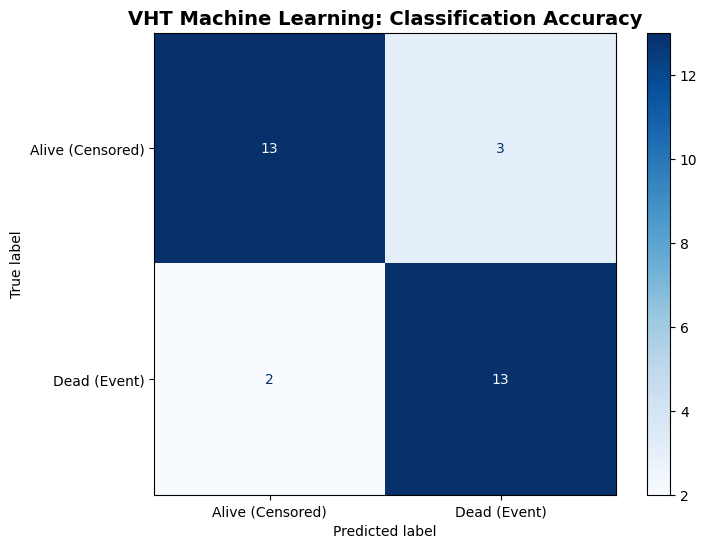

 VHT Matrix Complete: 46 components explain 99% variance.

 TOP DRIVERS OF VHT SIGNATURE (PC1):
Index(['Cycle length of Additional Therapy (q days)', 'Number of Fractions',
       'Number of Days from Diagnosis to Starting Additional Therapy ',
       'Number of days from Diagnosis to date of Further Progression',
       'Number of Days from Diagnosis to Starting 2nd_Additional Therapy ',
       'Number of Days from Diagnosis to Start Immunotherapy ',
       'Multiple surgeries', 'Days from Diagnosis to new treatment',
       ' Number of days from Diagnosis to Initial Chemo Therapy end date',
       'Number of days from Diagnosis to date of First Progression'],
      dtype='object')


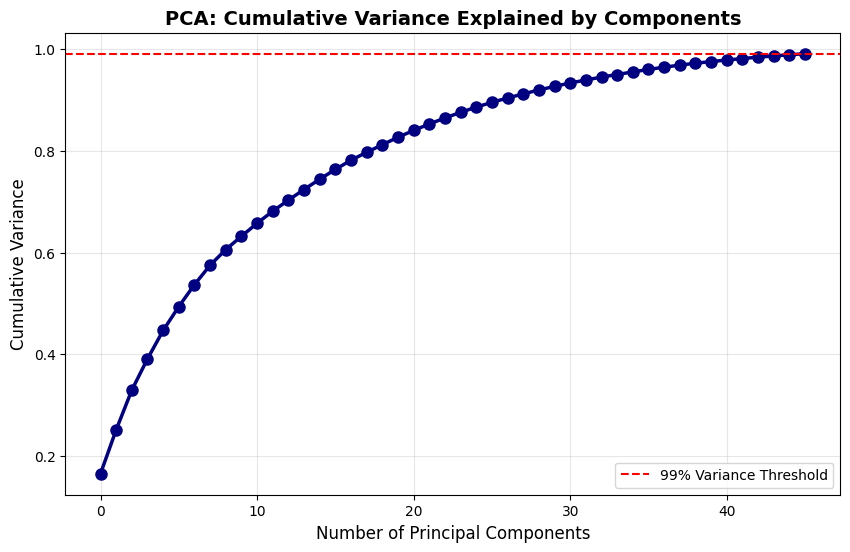

/var/folders/b9/x77syzb94gdggfcpp713pvjm0000gn/T/ipykernel_72487/3832089938.py:260: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=pc1_loadings.head(10).index, x=pc1_loadings.head(10).values, palette='viridis')


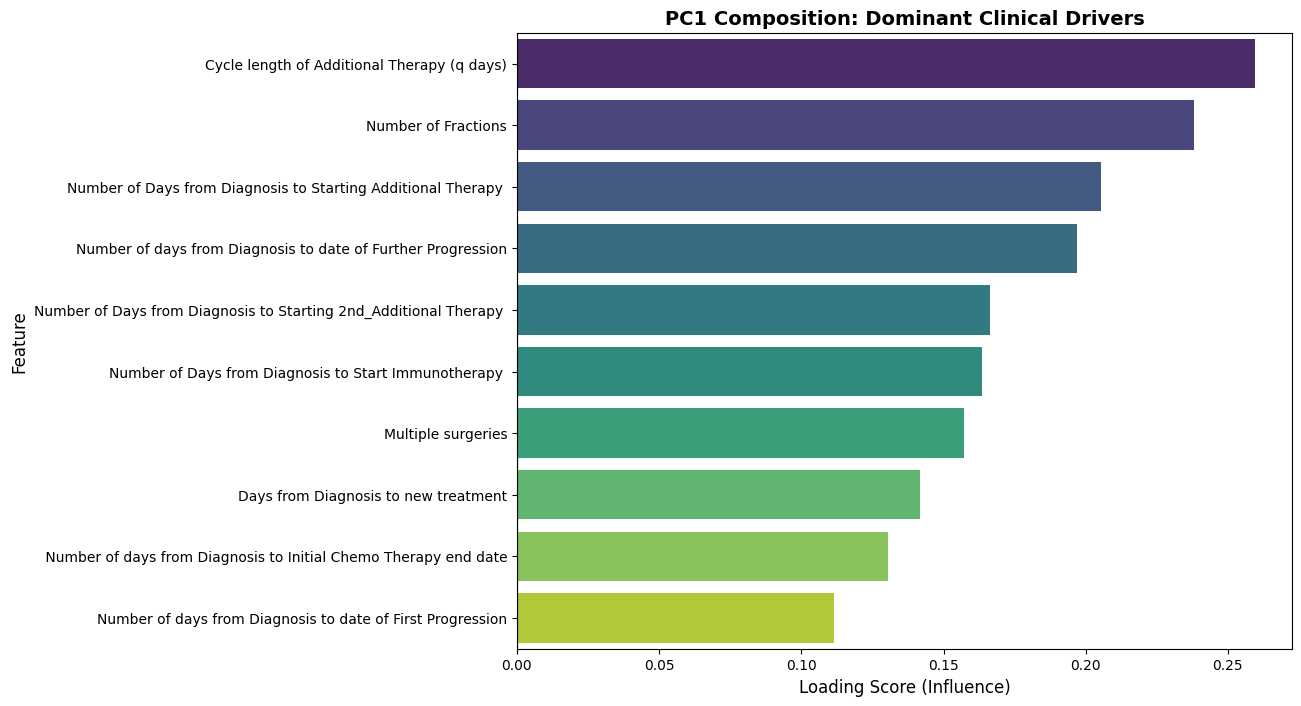

<lifelines.CoxPHFitter: fitted with 203 total observations, 106 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 203
number of events observed = 97
   partial log-likelihood = -340.22
         time fit was run = 2026-05-18 13:07:26 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
PC1       -0.20      0.82      0.04           -0.27           -0.13                0.77                0.88
PC2       -0.20      0.82      0.06           -0.31           -0.09                0.73                0.92
PC3       -0.07      0.93      0.05           -0.16            0.03                0.85                1.03
PC4        0.01      1.01      0.06           -0.11            0.13                0.89                1.14
PC5        0.06      1.06      0.05           -0.05            0.16                0.95                1.18
PC6        0.08      1.08      0.07           -0.06            0.22                0.94                1.25
PC7        0.07      1.08      0.06           -0.05            0.20                0.95                1.22
PC8        0.11      1.12      0.07           -0.02            0.24                0.98                1.27
PC9       -0.06      0.94      0.09           -0.24            0.11                0.79                1.12
PC10       0.05      1.06      0.10           -0.14            0.25                0.87                1.28
PC11       0.01      1.01      0.08           -0.16            0.17                0.85                1.19
PC12       0.14      1.15      0.10           -0.05            0.34                0.95                1.40
PC13      -0.01      0.99      0.09           -0.19            0.17                0.83                1.19
PC14      -0.08      0.92      0.11           -0.29            0.13                0.75                1.14
PC15      -0.29      0.75      0.11           -0.51           -0.07                0.60                0.93
PC16      -0.02      0.98      0.10           -0.22            0.17                0.80                1.19
PC17       0.02      1.02      0.11           -0.20            0.24                0.82                1.27
PC18       0.10      1.10      0.12           -0.13            0.32                0.88                1.38
PC19       0.25      1.28      0.12            0.02            0.48                1.02                1.62
PC20       0.10      1.10      0.13           -0.16            0.35                0.85                1.42
PC21       0.09      1.09      0.11           -0.14            0.31                0.87                1.37
PC22       0.34      1.40      0.14            0.05            0.62                1.05                1.86
PC23      -0.13      0.88      0.14           -0.40            0.15                0.67                1.16
PC24       0.17      1.19      0.15           -0.12            0.46                0.89                1.58
PC25      -0.21      0.81      0.17           -0.54            0.13                0.58                1.14
PC26       0.01      1.01      0.14           -0.27            0.29                0.76                1.33
PC27      -0.01      0.99      0.16           -0.32            0.30                0.72                1.35
PC28      -0.03      0.97      0.17           -0.35            0.29                0.70                1.34
PC29      -0.09      0.91      0.16           -0.42            0.23                0.66                1.26
PC30       0.12      1.13      0.16           -0.19            0.43                0.83                1.54
PC31      -0.51      0.60      0.20           -0.90           -0.12                0.41                0.88
PC32       0

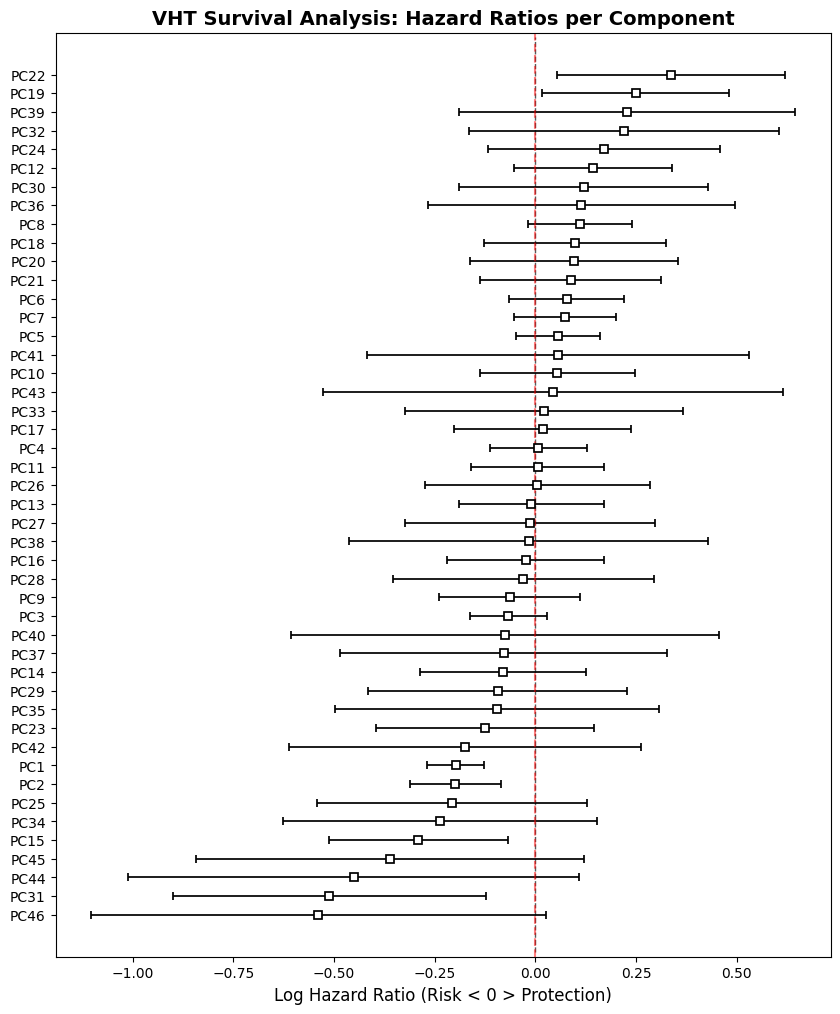

In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from lifelines import CoxPHFitter
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ======================================================================================
# 1. SETUP & LONGITUDINAL EXTRACTION (Refined)
# ======================================================================================
image_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post")
seg_vol_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_Segmentation_Volumes.xlsx")
clinical_path = Path("/Users/kasunachinthaperera/Documents/Final Year Project:Thesis/Data/PKG - MU-Glioma-Post/MU-Glioma-Post_ClinicalData-July2025.xlsx")

segmentation_labels = {1: "Necrotic", 2: "Edema", 3: "Enhancing", 4: "Resection"}
label_map = {
    "Necrotic Tumor Core (Label1)": "Necrotic",
    "Tumor Infiltration and Edema": "Edema",
    "Enhancing Tumor Core (Label3)": "Enhancing",
    "Resection Cavity (Label4)": "Resection"
}

# ======================================================================================
# 2. LOAD RADIOMIC MASTER SEQUENCES (Ordered by Patient/Visit)
# ======================================================================================
print(" Extracting longitudinal radiomic sequences...")
# Using a single container for master dicts to prevent variable shadowing
m_dict = {k: {} for k in ['vol', 'vox', 't1cm', 't1cs', 't1nm', 't1ns', 't2fm', 't2fs', 't2wm', 't2ws']}

seg_file = pd.ExcelFile(seg_vol_path)
for sheet in seg_file.sheet_names:
    df = pd.read_excel(seg_vol_path, sheet_name=sheet)
    df.columns = df.columns.str.strip()
    
    if 'Patient ID' in df.columns:
        df['PID_Clean'] = df['Patient ID'].astype(str).str.split('-').str[0]
        label_key = label_map.get(sheet, sheet)
        group = df.groupby('PID_Clean')
        
        # Mapping by index (3-12) ensures robustness against slight naming changes in Excel
        m_dict['vox'][label_key]  = group[df.columns[3]].apply(list).to_dict()
        m_dict['vol'][label_key]  = group[df.columns[4]].apply(list).to_dict()
        m_dict['t1cm'][label_key] = group[df.columns[5]].apply(list).to_dict()
        m_dict['t1cs'][label_key] = group[df.columns[6]].apply(list).to_dict()
        m_dict['t1nm'][label_key] = group[df.columns[7]].apply(list).to_dict()
        m_dict['t1ns'][label_key] = group[df.columns[8]].apply(list).to_dict()
        m_dict['t2fm'][label_key] = group[df.columns[9]].apply(list).to_dict()
        m_dict['t2fs'][label_key] = group[df.columns[10]].apply(list).to_dict()
        m_dict['t2wm'][label_key] = group[df.columns[11]].apply(list).to_dict()
        m_dict['t2ws'][label_key] = group[df.columns[12]].apply(list).to_dict()

clinical_df = pd.read_excel(clinical_path, sheet_name='MU Glioma Post')
clinical_df['PID_Clean'] = clinical_df['Patient ID'].astype(str).str.split('-').str[0]
clinical_data = clinical_df.set_index('PID_Clean').to_dict(orient='index')

patient_ids = sorted([d for d in os.listdir(image_path) if (image_path/d).is_dir() and not d.startswith('.')])
patient_objects = {}

print(" Building integrated VHT Patient objects...")
for pid in patient_ids:
    clean_id = pid.split('-')[0]
    p_folder = image_path / pid
    tps = sorted([t.name for t in p_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
    
    obj = {
        'Patient_ID': pid, 
        'clinical': clinical_data.get(clean_id, {}), 
        'timepoints': tps,
        'images': {}, 'volumes': {}, 'voxels': {},
        't1c_mean': {}, 't1c_stdevs': {}, 't1n_mean': {}, 't1n_stdevs': {},
        't2f_mean': {}, 't2f_stdevs': {}, 't2w_mean': {}, 't2w_stdevs': {}
    }

    for i, tp in enumerate(tps):
        obj['images'][tp] = [str(f) for f in (p_folder/tp).glob("*.nii*")]
        for l_name in m_dict['vol'].keys():
            # Helper to pull the i-th scan in the sequence safely
            def get_val(key): 
                seq = m_dict[key].get(l_name, {}).get(clean_id, [])
                return seq[i] if i < len(seq) else 0

            obj['volumes'].setdefault(tp, {})[l_name] = float(get_val('vol'))
            obj['voxels'].setdefault(tp, {})[l_name] = int(get_val('vox'))
            obj['t1c_mean'].setdefault(tp, {})[l_name] = float(get_val('t1cm'))
            obj['t1c_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1cs'))
            obj['t1n_mean'].setdefault(tp, {})[l_name] = float(get_val('t1nm'))
            obj['t1n_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1ns'))
            obj['t2f_mean'].setdefault(tp, {})[l_name] = float(get_val('t2fm'))
            obj['t2f_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2fs'))
            obj['t2w_mean'].setdefault(tp, {})[l_name] = float(get_val('t2wm'))
            obj['t2w_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2ws'))
    
    patient_objects[pid] = obj

# ======================================================================================
# 3. FEATURE ENGINEERING: TRANSFORM KINETICS INTO SCALARS
# ======================================================================================
print(" Converting Longitudinal Kinetics into VHT Behavioral Features...")
kinetic_features = []

for pid, obj in patient_objects.items():
    clean_id = pid.split('-')[0]
    history = None
    
    rates = {f"Vel_{lbl}": [] for lbl in label_map.values()}
    intensity_drifts = {f"Drift_{lbl}_{seq}_{stat}": [] 
                        for lbl in label_map.values() 
                        for seq in ['t1c', 't2f', 't1n', 't2w']
                        for stat in ['mean', 'stdev']}

    # Ensure timepoints are sorted (e.g., Post-treatment_1, _2, _3)
    for tp in sorted(obj['timepoints']):
        # Extract digits: "Post-treatment_1" -> "1"
        tp_num = "".join(filter(str.isdigit, tp))
        
        # --- FIX: Find the correct key in the clinical dict that contains (Timepoint_X) ---
        # We look for any key that has "Timepoint_1", "Timepoint_2", etc. inside it
        day_key = [k for k in obj['clinical'].keys() if f"Timepoint_{tp_num}" in k]
        day = float(obj['clinical'][day_key[0]]) if day_key else np.nan
        
        if history and not np.isnan(day) and not np.isnan(history['day']):
            dt = day - history['day']
            
            # Only calculate if there is a measurable gap in time
            if dt > 0:
                for lbl in label_map.values():
                    # 1. Growth Velocity
                    v_now = obj['volumes'].get(tp, {}).get(lbl, 0)
                    v_prev = history['vols'].get(lbl, 0)
                    rates[f"Vel_{lbl}"].append((v_now - v_prev) / dt)
                    
                    # 2. Intensity Drifts (Mean & Stdev)
                    # Helper to map sequences to internal object keys
                    seq_map = [
                        ('t1c', 't1c_mean', 't1c_stdevs'),
                        ('t2f', 't2f_mean', 't2f_stdevs'),
                        ('t1n', 't1n_mean', 't1n_stdevs'),
                        ('t2w', 't2w_mean', 't2w_stdevs')
                    ]
                    
                    for seq_short, mean_key, std_key in seq_map:
                        # Mean Drift
                        m_now = obj[mean_key].get(tp, {}).get(lbl, 0)
                        m_prev = history[f'{seq_short}_m'].get(lbl, 0)
                        intensity_drifts[f"Drift_{lbl}_{seq_short}_mean"].append((m_now - m_prev) / dt)
                        
                        # Stdev Drift
                        s_now = obj[std_key].get(tp, {}).get(lbl, 0)
                        s_prev = history[f'{seq_short}_s'].get(lbl, 0)
                        intensity_drifts[f"Drift_{lbl}_{seq_short}_stdev"].append((s_now - s_prev) / dt)

        # Update history for the next timepoint comparison
        history = {
            'day': day, 
            'vols': obj['volumes'].get(tp, {}),
            't1c_m': obj['t1c_mean'].get(tp, {}), 't1c_s': obj['t1c_stdevs'].get(tp, {}),
            't2f_m': obj['t2f_mean'].get(tp, {}), 't2f_s': obj['t2f_stdevs'].get(tp, {}),
            't1n_m': obj['t1n_mean'].get(tp, {}), 't1n_s': obj['t1n_stdevs'].get(tp, {}),
            't2w_m': obj['t2w_mean'].get(tp, {}), 't2w_s': obj['t2w_stdevs'].get(tp, {})
        }

    # Aggregate lists into mean scalars
    vht_row = {'PID_Clean': clean_id}
    for k, v in rates.items(): vht_row[k] = np.mean(v) if v else 0
    for k, v in intensity_drifts.items(): vht_row[k] = np.mean(v) if v else 0
    kinetic_features.append(vht_row)

df_kinetics = pd.DataFrame(kinetic_features)

# ======================================================================================
# 4. MERGING & CLEANING FOR ML
# ======================================================================================
df_clinical = pd.read_excel(clinical_path, sheet_name='MU Glioma Post')
df_clinical['PID_Clean'] = df_clinical['Patient ID'].astype(str).str.split('-').str[0]

# Combine Baseline Clinical + Engineered Kinetic Rates
#df_vht = pd.merge(df_clinical, df_kinetics, on='PID_Clean', how='inner')
df_vht = df_clinical

# Identify targets and drop metadata
targets = ['Overall Survival (Death)', 'Number of days from Diagnosis to death (Days)']
exclude = targets + ['Patient ID', 'PID_Clean', 'Hospice', 'Time to First Progression (Days)', 'Progression',
    'Type of 1st Progression',             # Outcome variable
    'Second Progression/Recurrence',    # Outcome variable
    'Type of 2nd Progression',         # Outcome variable
    'Second Progression/Recurrence',    # Outcome variable
    'Number of Days from Diagnosis to 1st MRI (Timepoint_1) ',  # Time variable
    'Number of Days from Diagnosis to 2nd MRI (Timepoint_2) ',  # Time variable
    'Number of Days from Diagnosis to 3rd MRI (Timepoint_3) ',  # Time variable
    'Number of Days from Diagnosis to 4th MRI (Timepoint_4) ',  # Time variable
    'Number of Days from Diagnosis to 5th MRI (Timepoint_5) ',  # Time variable
    'Number of Days from Diagnosis to 6th MRI (Timepoint_6) '   # Time variable
]
X_raw = df_vht.drop(columns=[c for c in exclude if c in df_vht.columns])

# Standard Preprocessing
for col in X_raw.select_dtypes(include=['object']).columns:
    X_raw[col] = LabelEncoder().fit_transform(X_raw[col].astype(str))
X_raw = X_raw.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
pca = PCA(n_components=0.99)
X_pca = pca.fit_transform(X_scaled)

# Prepare y for the split to ensure we reference the actual data, not the name list
y_labels = df_vht[targets[0]].astype(int)

X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y_labels, test_size=0.15, random_state=42, stratify=y_labels
)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_pca, y_train)

clf_pca = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42)
clf_pca.fit(X_train_smote, y_train_smote)

# We use y_test (actual values) instead of targets (list of names)
y_pred = clf_pca.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred)

# Plotting fix: disp.plot creates its own axis, we just need to set the title after
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Alive (Censored)', 'Dead (Event)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title('VHT Machine Learning: Classification Accuracy', fontsize=14, fontweight='bold')
plt.show()

# ======================================================================================
# 5. VHT SIGNATURE ANALYSIS (PCA)
# ======================================================================================
print(f" VHT Matrix Complete: {X_pca.shape[1]} components explain 99% variance.")

# Show top drivers of PC1 (Now includes Velocities!)
pc1_drivers = pd.Series(pca.components_[0], index=X_raw.columns).sort_values(ascending=False)
print("\n TOP DRIVERS OF VHT SIGNATURE (PC1):")
print(pc1_drivers.head(10).index)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), 'o-', color='navy', linewidth=2.5, markersize=8)
plt.axhline(y=0.99, color='red', linestyle='--', label='99% Variance Threshold')
plt.title('PCA: Cumulative Variance Explained by Components', fontsize=14, fontweight='bold')
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Variance', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 8))
pc1_loadings = pd.Series(pca.components_[0], index=X_raw.columns).sort_values(ascending=False)
sns.barplot(y=pc1_loadings.head(10).index, x=pc1_loadings.head(10).values, palette='viridis')
plt.title('PC1 Composition: Dominant Clinical Drivers', fontsize=14, fontweight='bold')
plt.xlabel('Loading Score (Influence)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

# ======================================================================================
# 6. SURVIVAL MODELING (COX PCA)
# ======================================================================================
df_cox_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
df_cox_pca['duration'] = df_vht['Number of days from Diagnosis to death (Days)'].fillna(df_vht['Time to First Progression (Days)']).fillna(1).values
df_cox_pca['event'] = df_vht['Overall Survival (Death)'].astype(int).values

cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_cox_pca[df_cox_pca['duration'] > 0], duration_col='duration', event_col='event')
cph.print_summary()

# D. COX HAZARD RATIO FOREST PLOT
plt.figure(figsize=(10, 12))
cph.plot()
plt.title('VHT Survival Analysis: Hazard Ratios per Component', fontsize=14, fontweight='bold')
plt.xlabel('Log Hazard Ratio (Risk < 0 > Protection)', fontsize=12)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

In [23]:
import nibabel as nib
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.multioutput import MultiOutputRegressor

# ======================================================================================
# 1. LOAD RADIOMIC MASTER SEQUENCES (Ordered by Patient/Visit)
# ======================================================================================
print(" Extracting longitudinal radiomic sequences...")
# Using a single container for master dicts to prevent variable shadowing
m_dict = {k: {} for k in ['vol', 'vox', 't1cm', 't1cs', 't1nm', 't1ns', 't2fm', 't2fs', 't2wm', 't2ws']}

seg_file = pd.ExcelFile(seg_vol_path)
for sheet in seg_file.sheet_names:
    df = pd.read_excel(seg_vol_path, sheet_name=sheet)
    df.columns = df.columns.str.strip()
    
    if 'Patient ID' in df.columns:
        df['PID_Clean'] = df['Patient ID'].astype(str).str.split('-').str[0]
        label_key = label_map.get(sheet, sheet)
        group = df.groupby('PID_Clean')
        
        # Mapping by index (3-12) ensures robustness against slight naming changes in Excel
        m_dict['vox'][label_key]  = group[df.columns[3]].apply(list).to_dict()
        m_dict['vol'][label_key]  = group[df.columns[4]].apply(list).to_dict()
        m_dict['t1cm'][label_key] = group[df.columns[5]].apply(list).to_dict()
        m_dict['t1cs'][label_key] = group[df.columns[6]].apply(list).to_dict()
        m_dict['t1nm'][label_key] = group[df.columns[7]].apply(list).to_dict()
        m_dict['t1ns'][label_key] = group[df.columns[8]].apply(list).to_dict()
        m_dict['t2fm'][label_key] = group[df.columns[9]].apply(list).to_dict()
        m_dict['t2fs'][label_key] = group[df.columns[10]].apply(list).to_dict()
        m_dict['t2wm'][label_key] = group[df.columns[11]].apply(list).to_dict()
        m_dict['t2ws'][label_key] = group[df.columns[12]].apply(list).to_dict()

clinical_df = pd.read_excel(clinical_path, sheet_name='MU Glioma Post')
clinical_df['PID_Clean'] = clinical_df['Patient ID'].astype(str).str.split('-').str[0]
clinical_data = clinical_df.set_index('PID_Clean').to_dict(orient='index')

patient_ids = sorted([d for d in os.listdir(image_path) if (image_path/d).is_dir() and not d.startswith('.')])
patient_objects = {}

print(" Building integrated VHT Patient objects...")
for pid in patient_ids:
    clean_id = pid.split('-')[0]
    p_folder = image_path / pid
    tps = sorted([t.name for t in p_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
    
    obj = {
        'Patient_ID': pid, 
        'clinical': clinical_data.get(clean_id, {}), 
        'timepoints': tps,
        'images': {}, 'volumes': {}, 'voxels': {},
        't1c_mean': {}, 't1c_stdevs': {}, 't1n_mean': {}, 't1n_stdevs': {},
        't2f_mean': {}, 't2f_stdevs': {}, 't2w_mean': {}, 't2w_stdevs': {}
    }

   # Inside the loop: for pid in patient_ids:
    p_folder = image_path / pid
    tps = sorted([t.name for t in p_folder.iterdir() if t.is_dir() and not t.name.startswith('.')])
    
    # ADJUSTMENT: Filter for longitudinal data (2+ timepoints)
    if len(tps) >= 2:
        obj = {
            'Patient_ID': pid, 
            'clinical': clinical_data.get(clean_id, {}), 
            'timepoints': tps,
            'images': {}, 'volumes': {}, 'voxels': {},
            't1c_mean': {}, 't1c_stdevs': {}, 't1n_mean': {}, 't1n_stdevs': {},
            't2f_mean': {}, 't2f_stdevs': {}, 't2w_mean': {}, 't2w_stdevs': {}
        }

        for i, tp in enumerate(tps):
            obj['images'][tp] = [str(f) for f in (p_folder/tp).glob("*.nii*")]
            for l_name in m_dict['vol'].keys():
                # Helper to pull the i-th scan in the sequence safely
                def get_val(key): 
                    seq = m_dict[key].get(l_name, {}).get(clean_id, [])
                    # Safety check: ensure sequence length matches timepoint index
                    return seq[i] if i < len(seq) else 0

                obj['volumes'].setdefault(tp, {})[l_name] = float(get_val('vol'))
                obj['voxels'].setdefault(tp, {})[l_name] = int(get_val('vox'))
                obj['t1c_mean'].setdefault(tp, {})[l_name] = float(get_val('t1cm'))
                obj['t1c_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1cs'))
                obj['t1n_mean'].setdefault(tp, {})[l_name] = float(get_val('t1nm'))
                obj['t1n_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t1ns'))
                obj['t2f_mean'].setdefault(tp, {})[l_name] = float(get_val('t2fm'))
                obj['t2f_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2fs'))
                obj['t2w_mean'].setdefault(tp, {})[l_name] = float(get_val('t2wm'))
                obj['t2w_stdevs'].setdefault(tp, {})[l_name] = float(get_val('t2ws'))
        
        patient_objects[pid] = obj



 Extracting longitudinal radiomic sequences...
 Building integrated VHT Patient objects...


In [24]:
# ======================================================================================
# 2. ENHANCED FEATURE ENGINEERING: BIOLOGICAL PRIORS & TREATMENT MODIFIERS
# ======================================================================================
print(" Extracting Treatment Exposures & Molecular Priors for VHT Calibration...")

from sklearn.preprocessing import LabelEncoder

# Define molecular markers to be used as 'Biologically Grounded Priors'
biological_priors = [
    'IDH1 mutation', 'IDH2 mutation', 'MGMT methylation', '1p/19q',
    'ATRX mutation', 'BRAF V600E mutation', 'TERT promoter mutation',
    'Chromosome 7 gain and Chromosome 10 loss', 'H3-3A mutation',
    'EGFR amplification', 'PTEN mutation', 'CDKN2A/B deletion',
    'TP53 alteration', 'Grade of Primary Brain Tumor'
]

treatment_columns = [
    'Initial Chemo Therapy', 'Radiation Therapy', 'Dose', 'Number of Fractions',
    'Additional Therapy', '2nd_Additional Therapy', 'Immuno therapy', 'Brachy therapy'
]

# Standard Preprocessing
for item in biological_priors:
    if item in X_raw.columns:
        X_raw[item] = LabelEncoder().fit_transform(X_raw[item].astype(str))

for item in treatment_columns:
    if item in X_raw.columns:
        X_raw[item] = LabelEncoder().fit_transform(X_raw[item].astype(str))

X_raw = X_raw.fillna(0)
kinetic_features = []

for pid, obj in patient_objects.items():
    clean_id = pid.split('-')[0]
    clinical = obj['clinical']
    history = None
    
    # Capture Treatment Metadata (Mechanistic Components)
    chemo_day = float(clinical.get(' Number of days from Diagnosis to Initial Chemo Therapy Start date', np.nan))
    rad_day = float(clinical.get('Number of days from Diagnosis to Radiation Therapy Start date', np.nan))
    
    rates = {f"Vel_{lbl}": [] for lbl in label_map.values()}
    
    for tp in sorted(obj['timepoints']):
        tp_num = "".join(filter(str.isdigit, tp))
        day_key = [k for k in clinical.keys() if f"Timepoint_{tp_num}" in k]
        day = float(clinical[day_key[0]]) if day_key else np.nan
        
        if history and not np.isnan(day) and not np.isnan(history['day']):
            dt = day - history['day']
            if dt > 0:
                for lbl in label_map.values():
                    v_now = obj['volumes'].get(tp, {}).get(lbl, 0)
                    v_prev = history['vols'].get(lbl, 0)
                    # Measuring 'Residual Dynamics' (v_now - v_prev) / dt
                    rates[f"Vel_{lbl}"].append((v_now - v_prev) / dt)

        history = {'day': day, 'vols': obj['volumes'].get(tp, {})}

    # Create VHT Feature Row
    vht_row = {'PID_Clean': clean_id}
    # Average the kinetics (The 'Latent Adaptation' component)
    for k, v in rates.items(): vht_row[k] = np.mean(v) if v else 0
    
    # Assimilate Biological Constraints
    for marker in biological_priors:
        vht_row[marker] = clinical.get(marker, 0) # Assumes encoded/numeric markers
        
    # Assimilate Treatment Perturbations
    vht_row['Post_Chemo'] = 1 if not np.isnan(chemo_day) else 0
    vht_row['Post_Rad'] = 1 if not np.isnan(rad_day) else 0
    
    kinetic_features.append(vht_row)

df_kinetics = pd.DataFrame(kinetic_features).fillna(0)



 Extracting Treatment Exposures & Molecular Priors for VHT Calibration...


In [ ]:
# ======================================================================================
# 3. HYBRID BAYESIAN VHT FORECASTER: Mechanistic + Data-Driven Fusion
# ======================================================================================

def get_initial_mask_volume(obj):
    tps = sorted(obj.get('timepoints', []))
    if len(tps) == 0:
        return np.nan

    first_tp = tps[0]
    mask_path = next(
        (p for p in obj.get('images', {}).get(first_tp, []) if "mask" in Path(p).name.lower()),
        None
    )
    if mask_path is None:
        return np.nan

    img = nib.load(mask_path)
    mask_data = img.get_fdata()
    voxel_volume = float(np.prod(img.header.get_zooms()[:3]))

    total = 0.0
    for lbl in [1, 2, 3, 4]:
        total += float(np.sum(mask_data == lbl)) * voxel_volume

    return total if total > 0 else np.nan


def estimate_vmax_prior_from_masks(patient_objects, factor=2.0, percentile=95):
    initial_volumes = []
    for pid, obj in patient_objects.items():
        v0 = get_initial_mask_volume(obj)
        if pd.notna(v0):
            initial_volumes.append(v0)
    if len(initial_volumes) == 0:
        return 500000.0
    p = np.percentile(initial_volumes, percentile)
    return float(max(factor * p, 1.0))


def volume_to_radius(volume):
    volume = float(volume) if pd.notna(volume) else np.nan
    if pd.isna(volume) or volume <= 0:
        return np.nan
    return (3.0 * volume / (4.0 * np.pi)) ** (1.0 / 3.0)


def get_mask_volume_at_tp(obj, tp):
    mask_path = next(
        (p for p in obj.get('images', {}).get(tp, []) if "mask" in Path(p).name.lower()),
        None
    )
    if mask_path is None:
        return np.nan

    img = nib.load(mask_path)
    mask_data = img.get_fdata()
    voxel_volume = float(np.prod(img.header.get_zooms()[:3]))

    total = 0.0
    for lbl in [1, 2, 3, 4]:
        total += float(np.sum(mask_data == lbl)) * voxel_volume

    return total if total > 0 else np.nan


def estimate_fisher_kpp_velocity(volume, rho=0.01, V_max=500000, volume_prev=None, dt=1.0):
    volume = float(volume) if pd.notna(volume) else np.nan
    if pd.isna(volume) or volume <= 0:
        return np.nan

    r_now = volume_to_radius(volume)
    if pd.isna(r_now):
        return np.nan

    if volume_prev is not None and pd.notna(volume_prev) and dt > 0:
        volume_prev = float(volume_prev)
        if volume_prev > 0:
            r_prev = volume_to_radius(volume_prev)
            if pd.notna(r_prev):
                return (r_now - r_prev) / float(dt)

    drdt = rho * r_now * (1.0 - volume / V_max)
    return 4.0 * np.pi * (r_now ** 2) * drdt


# --- STEP 0: COHORT-BASED V_MAX PRIOR FROM INITIAL MASK VOLUMES ---
V_max_prior = estimate_vmax_prior_from_masks(patient_objects, factor=2.0, percentile=95)


# --- STEP 1: ALIGN PATIENT ORDER ---
df_kinetics = df_kinetics.copy()
df_kinetics['PID_Clean'] = df_kinetics['PID_Clean'].astype(str)

if 'PID_Clean' not in df_cox_pca.columns:
    df_cox_pca['PID_Clean'] = clinical_df['PID_Clean'].values

longitudinal_pids = df_kinetics['PID_Clean'].unique()

df_vht_clinical = df_cox_pca[df_cox_pca['PID_Clean'].isin(longitudinal_pids)].copy()
df_vht_clinical = df_vht_clinical.set_index('PID_Clean').reindex(longitudinal_pids).reset_index()

df_kinetics = df_kinetics.set_index('PID_Clean').reindex(longitudinal_pids).reset_index()



# --- STEP 2: BUILD TARGETS AND FEATURES ---
forecast_targets = ['Vel_Necrotic', 'Vel_Edema', 'Vel_Enhancing', 'Vel_Resection']
y_observed = df_kinetics[forecast_targets].to_numpy(dtype=float)

y_mechanistic = []
for pid in longitudinal_pids:
    obj = next((patient_objects[k] for k in patient_objects.keys() if pid in k), None)
    if obj is None or len(obj.get('timepoints', [])) == 0:
        y_mechanistic.append([np.nan] * len(label_map.values()))
        continue

    tps = sorted(obj['timepoints'])
    latest_tp = tps[-1]
    prev_tp = tps[-2] if len(tps) > 1 else None

    latest_vol = get_mask_volume_at_tp(obj, latest_tp)
    prev_vol = get_mask_volume_at_tp(obj, prev_tp) if prev_tp is not None else np.nan

    dt = np.nan
    if prev_tp is not None:
        dt = 1.0
        try:
            latest_day_key = [k for k in obj['clinical'].keys() if f"Timepoint_{''.join(filter(str.isdigit, latest_tp))}" in str(k)]
            prev_day_key = [k for k in obj['clinical'].keys() if f"Timepoint_{''.join(filter(str.isdigit, prev_tp))}" in str(k)]
            if len(latest_day_key) > 0 and len(prev_day_key) > 0:
                latest_day = float(obj['clinical'][latest_day_key[0]])
                prev_day = float(obj['clinical'][prev_day_key[0]])
                dt = latest_day - prev_day
                if dt <= 0:
                    dt = np.nan
        except:
            dt = np.nan

    mech_row = []
    for lbl in label_map.values():
        if pd.notna(latest_vol) and pd.notna(prev_vol) and pd.notna(dt):
            mech_row.append(
                estimate_fisher_kpp_velocity(
                    latest_vol,
                    rho=0.01,
                    V_max=V_max_prior,
                    volume_prev=prev_vol,
                    dt=dt
                )
            )
        else:
            mech_row.append(
                estimate_fisher_kpp_velocity(
                    latest_vol,
                    rho=0.01,
                    V_max=V_max_prior
                )
            )

    y_mechanistic.append(mech_row)

y_mechanistic = np.array(y_mechanistic, dtype=float)



# --- STEP 3: FILTER VALID ROWS ---
valid_mask = np.isfinite(y_observed).all(axis=1) & np.isfinite(y_mechanistic).all(axis=1)

y_observed = y_observed[valid_mask]
y_mechanistic = y_mechanistic[valid_mask]
df_kinetics_valid = df_kinetics.loc[valid_mask].reset_index(drop=True)
df_vht_clinical = df_vht_clinical.loc[valid_mask].reset_index(drop=True)

y_residuals = y_observed - y_mechanistic



# --- STEP 4: BUILD INTEGRATED FEATURES ---
X_pca_aligned = df_vht_clinical.drop(columns=['PID_Clean', 'risk_score'], errors='ignore').copy()

for col in X_pca_aligned.columns:
    if X_pca_aligned[col].dtype == 'object':
        X_pca_aligned[col] = LabelEncoder().fit_transform(X_pca_aligned[col].astype(str))

X_pca_aligned = X_pca_aligned.to_numpy(dtype=float)

X_bio_priors = df_kinetics_valid[biological_priors + ['Post_Chemo', 'Post_Rad']].to_numpy(dtype=float)

cox_feature_cols = [c for c in df_cox_pca.columns if c not in ['PID_Clean', 'risk_score']]
cox_input = df_vht_clinical[cox_feature_cols].copy()

for col in cox_input.columns:
    if cox_input[col].dtype == 'object':
        cox_input[col] = LabelEncoder().fit_transform(cox_input[col].astype(str))

df_vht_clinical['risk_score'] = cph.predict_partial_hazard(cox_input)
X_risk = df_vht_clinical['risk_score'].to_numpy(dtype=float).reshape(-1, 1)

X_vht_integrated = np.hstack([X_pca_aligned, X_bio_priors, X_risk])



# --- STEP 5: TRAIN RESIDUAL LEARNER ---
kernel = C(1.0) * RBF(10.0)
bayesian_residual_learner = MultiOutputRegressor(
    GaussianProcessRegressor(kernel=kernel, alpha=0.5, random_state=42)
)

print(f" Calibrating Hybrid VHT (Mechanistic Baseline + Residual Learner)... V_max_prior={V_max_prior:.2f}")
bayesian_residual_learner.fit(X_vht_integrated, y_residuals)

 Calibrating Hybrid VHT (Mechanistic Baseline + Residual Learner)... V_max_prior=356408.20


/Users/kasunachinthaperera/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kasunachinthaperera/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kasunachinthaperera/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.

MultiOutputRegressor(estimator=GaussianProcessRegressor(alpha=0.5,
                                                        kernel=1**2 * RBF(length_scale=10),
                                                        random_state=42))

In [40]:
# ======================================================================================
# 4. UPDATED 3D VISUALIZATION: Mechanistic-Stochastic Hybrid Projection
# ======================================================================================

def visualize_vht_3d_prediction(patient_idx, days):
    # 1. RETRIEVE PATIENT CONTEXT
    pid_clean = df_kinetics.iloc[patient_idx]['PID_Clean']
    
    # Locate the full patient object
    full_pid = next(k for k in patient_objects.keys() if pid_clean in k)
    patient = patient_objects[full_pid]
    latest_tp = sorted(patient['timepoints'])[-1]
    
    # Locate the latest mask path
    mask_path = next((p for p in patient['images'].get(latest_tp, []) if "mask" in Path(p).name.lower()), None)
    if not mask_path: 
        print(f"Error: Mask not found for {pid_clean}")
        return

    # 2. HYBRID INFERENCE (NEXUS-BRAIN Forward Pass)
    # A. Get Mechanistic Baseline (Fisher-KPP)
    # We calculate the growth based on current volumes
    latest_vols = [patient['volumes'][latest_tp].get(lbl, 0) for lbl in ['Necrotic', 'Edema', 'Enhancing', 'Resection']]
    mech_vel = np.array([estimate_fisher_kpp_velocity(v) for v in latest_vols])
    
    # B. Get Bayesian Residuals (The 'Neural ODE' part)
    signature = X_vht_integrated[patient_idx].reshape(1, -1)
    predicted_residuals = bayesian_residual_learner.predict(signature)[0]
    
    # C. Extract Epistemic Uncertainty (Standard Deviation)
    # This represents the AI's confidence in its correction
    uncertainties = [est.predict(signature, return_std=True)[1][0] 
                     for est in bayesian_residual_learner.estimators_]
    
    # D. Final Fusion: Growth = Biology + Correction
    final_velocities = mech_vel + predicted_residuals
    
    # Map back to labels (1: Necrotic, 2: Edema, 3: Enhancing, 4: Resection)
    vel_map = dict(zip([1, 2, 3, 4], final_velocities)) 
    uncert_map = dict(zip([1, 2, 3, 4], uncertainties))
    
    # 3. LOAD SPATIAL DATA
    img_obj = nib.load(mask_path)
    mask_data = img_obj.get_fdata()
    
    fig = plt.figure(figsize=(16, 8))
    colors = {1: "blue", 2: "green", 3: "red", 4: "yellow"}
    labels = {1: "Necrotic", 2: "Edema", 3: "Enhancing", 4: "Resection"}
    
    # --- SUBPLOT 1: CURRENT STATE ---
    ax1 = fig.add_subplot(121, projection='3d')
    for lvl, color in colors.items():
        z, y, x = np.where(mask_data == lvl)
        if len(x) > 0:
            ax1.scatter(x[::5], y[::5], z[::5], c=color, s=1, alpha=0.3, label=labels[lvl])
    ax1.set_title(f"CURRENT OBSERVED STATE\n({latest_tp})", fontsize=12, fontweight='bold')
    ax1.legend(loc='upper left')

    # --- SUBPLOT 2: HYBRID VHT PROJECTION ---
    ax2 = fig.add_subplot(122, projection='3d')
    for lvl, color in colors.items():
        z, y, x = np.where(mask_data == lvl)
        if len(x) > 0:
            # MEAN PROJECTION (Biology + AI Residual)
            # We scale the coordinates relative to the centroid
            scale_mean = 1 + (vel_map[lvl] * days / 10000)
            x_p = (x - np.mean(x)) * scale_mean + np.mean(x)
            y_p = (y - np.mean(y)) * scale_mean + np.mean(y)
            z_p = (z - np.mean(z)) * scale_mean + np.mean(z)
            ax2.scatter(x_p[::5], y_p[::5], z_p[::5], c=color, s=1, alpha=0.4)
            
            # UNCERTAINTY CLOUD (95% CI of the Residual Correction)
            # Visualizing the potential variance in the predicted trajectory
            scale_unc = scale_mean + (uncert_map[lvl] * days / 5000)
            x_u = (x - np.mean(x)) * scale_unc + np.mean(x)
            y_u = (y - np.mean(y)) * scale_unc + np.mean(y)
            z_u = (z - np.mean(z)) * scale_unc + np.mean(z)
            ax2.scatter(x_u[::10], y_u[::10], z_u[::10], c=color, s=0.5, alpha=0.05)
            
    # Metadata and Risk
    current_risk = df_vht_clinical['risk_score'].iloc[patient_idx]
    ax2.set_title(f"HYBRID VHT PROJECTION (+{days} Days)\nFusion: Fisher-KPP + Bayesian Residuals", 
                 fontsize=12, fontweight='bold')
    
    plt.suptitle(f"Virtual Health Twin Projection: Patient {pid_clean}\n"
                 f"Integrated Risk: {current_risk:.4f} | Features: PCA + Molecular Priors + Treatment", 
                 fontsize=15, y=0.95)
    
    ax1.view_init(20, 45); ax2.view_init(20, 45)
    plt.tight_layout()
    plt.show()

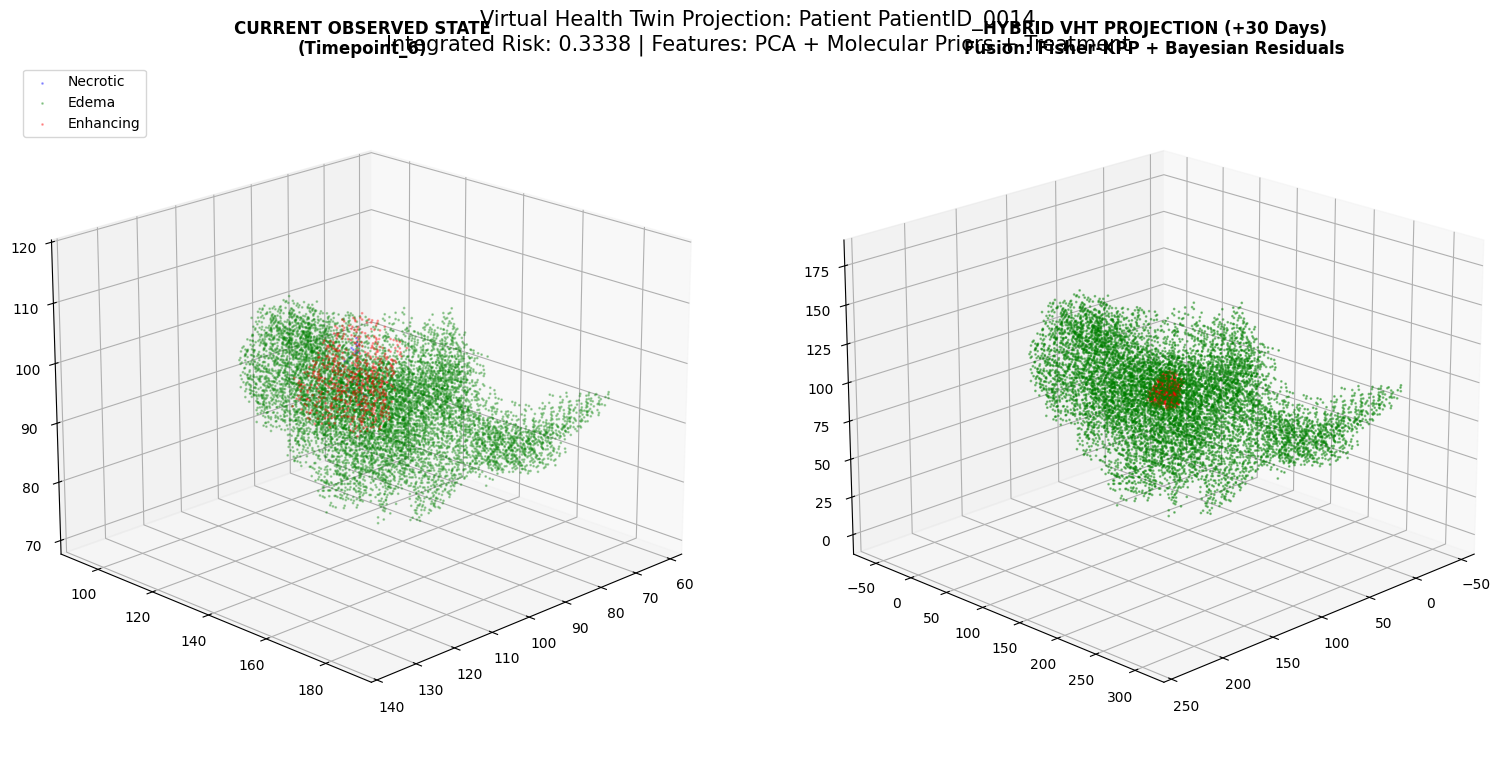

In [55]:
# Execution
visualize_vht_3d_prediction(patient_idx=9, days=30)

In [37]:
chemo_day=float(df_vht.iloc[0][' Number of days from Diagnosis to Initial Chemo Therapy Start date'])
print(f"Patient 1 Chemo Start Day: {chemo_day}")

Patient 1 Chemo Start Day: 26.0
